# Billboard Hot 100 — Dataöversikt för UX-teamet

> Dataset: Billboard Hot 100 (1958–2021) · ~330 000 rader · 7 kolumner

---

## Vad innehåller datan?

Varje rad representerar en låts placering på Billboard Hot 100 en specifik vecka.

| Kolumn | Typ | Exempel | Beskrivning |
|---|---|---|---|
| `date` | datum | `2021-11-06` | Veckan då listan publicerades |
| `rank` | heltal | `1` | Aktuell placering (1–100) |
| `song` | text | `Easy On Me` | Låtens titel |
| `artist` | text | `Adele` | Artist(er) |
| `last-week` | heltal / null | `1` | Placering föregående vecka (null = nykomling) |
| `peak-rank` | heltal | `1` | Bästa placering någonsin |
| `weeks-on-board` | heltal | `3` | Antal veckor på listan totalt |

---

## Möjliga analyser och visualiseringar

### 🎵 Artistanalys
- Vilka artister har haft flest låtar på listan?
- Vilka artister har haft längst total tid på listan?
- Karriärutveckling: hur har en artists prestationer förändrats över åren?

### 📈 Trendanalys över tid
- Hur länge stannade en typisk #1-låt i toppen på 60-talet vs 2020-talet?
- Har det blivit svårare eller lättare att nå #1?
- Säsongsmönster — finns det veckor på året då nya låtar presterar bättre?

### ⏱ Uthållighet
- Rekordet för flest veckor på listan (`weeks-on-board`)
- Låtar som klättrat upp igen efter att ha sjunkit (re-entry / "charting back up")
- Hur ofta debuterar en låt direkt på #1 vs klättrar dit gradvis?

### 🤝 Samarbeten (features)
- Artister i `artist`-kolumnen innehåller "Featuring" — vi kan extrahera featured artists
- Vilka duo-konstellationer har presterat bäst?
- Har antalet låtar med featured artists ökat över tid?

### 🗓 Dekadöversikt
- Topp-artister per decennium
- Genreskiften (kan delvis härledas ur artistnamn och tidsperiod)
- Jämförelse: hur dominerade enskilda artister listan på 60-talet vs 2020-talet?

---

## Tekniska noteringar

- **Nullvärden** förekommer i `last-week` för nykomlingar på listan — behöver hanteras i filter/aggregering.
- **Artist-fältet** innehåller ibland flera artister i ett och samma fält (t.ex. `"Nardo Wick Featuring G Herbo, Lil Durk & 21 Savage"`). Parsning krävs för artistspecifika analyser.
- **Datum** är alltid en lördag (Billboards publiceringsvecka) — bra att känna till vid tidsserievisualisering.
- **Datumspann**: 1958 v1 → 2021 v44 ≈ 63 år av veckodata.

---

## Förslag på UX-mönster

| Vy | Beskrivning |
|---|---|
| **Artistprofil** | Sök på en artist och se alla deras placeringar som en tidslinje |
| **Veckans lista** | Välj ett datum och se hela top 100 den veckan |
| **Låtens resa** | Välj en låt och visualisera hur den rört sig upp och ned på listan |
| **Dekadsfiltrer** | Filtrera allt innehåll per decennium för historiska jämförelser |
| **Race chart** | Animerad "bar chart race" med topp-artister vecka för vecka |

---

*Dokument sammanställt som underlag för vidare diskussion — inte en teknisk spec.*

In [3]:
from pathlib import Path
import pandas as pd
from matplotlib.pyplot import barh

# Get the notebook's directory, go up one level, then into data/bronze
bronze_path = Path.cwd().parent / 'data' / 'bronze'

df = pd.read_csv(bronze_path / 'charts.csv')

In [4]:
df.columns

Index(['date', 'rank', 'song', 'artist', 'last-week', 'peak-rank',
       'weeks-on-board'],
      dtype='str')

In [7]:
df.head()

,date,rank,song,artist,last-week,peak-rank,weeks-on-board
0,2021-11-06,1,Easy On Me,Adele,1.0,1,3
1,2021-11-06,2,Stay,The Kid LAROI & Justin Bieber,2.0,1,16
2,2021-11-06,3,Industry Baby,Lil Nas X & Jack Harlow,3.0,1,14
3,2021-11-06,4,Fancy Like,Walker Hayes,4.0,3,19
4,2021-11-06,5,Bad Habits,Ed Sheeran,5.0,2,18


In [16]:
# Top 10 artister med längsta streak
top10_artists = (df.groupby('artist')['weeks-on-board']
                   .max()
                   .sort_values(ascending=False)
                   .head(10)
                   .reset_index())
top10_artists.columns = ['artist', 'max_weeks']
top10_artists

,artist,max_weeks
0,The Weeknd,90
1,Imagine Dragons,87
2,AWOLNATION,79
3,Jason Mraz,76
4,LeAnn Rimes,69
5,OneRepublic,68
6,LMFAO Featuring Lauren Bennett & GoonRock,68
7,Adele,65
8,Jewel,65
9,Carrie Underwood,64


In [12]:
# Top 10 artister med flest veckor på listan (totalt)
top10_artists = (df.groupby('artist')['weeks-on-board']
                   .sum()
                   .sort_values(ascending=False)
                   .head(10)
                   .reset_index())
top10_artists.columns = ['artist', 'total_weeks']
top10_artists

,artist,total_weeks
0,Taylor Swift,13689
1,Imagine Dragons,10915
2,The Weeknd,9161
3,Madonna,8391
4,Elton John,8165
5,Mariah Carey,8049
6,Maroon 5,7957
7,Ed Sheeran,7956
8,Kelly Clarkson,7437
9,Rihanna,7404


In [9]:
# Dominant artist per decennium (flest list-tillfällen)
df['decade'] = (pd.to_datetime(df['date']).dt.year // 10 * 10).astype(str) + 's'

dominant_per_decade = (df.groupby(['decade', 'artist'])
                         .size()
                         .reset_index(name='appearances')
                         .sort_values('appearances', ascending=False)
                         .groupby('decade')
                         .first()
                         .reset_index())
dominant_per_decade

,decade,artist,appearances
0,1950s,Connie Francis,114
1,1960s,The Beatles,478
2,1970s,Bee Gees,333
3,1980s,Daryl Hall John Oates,363
4,1990s,Madonna,407
5,2000s,Rascal Flatts,454
6,2010s,Drake,683
7,2020s,Morgan Wallen,179


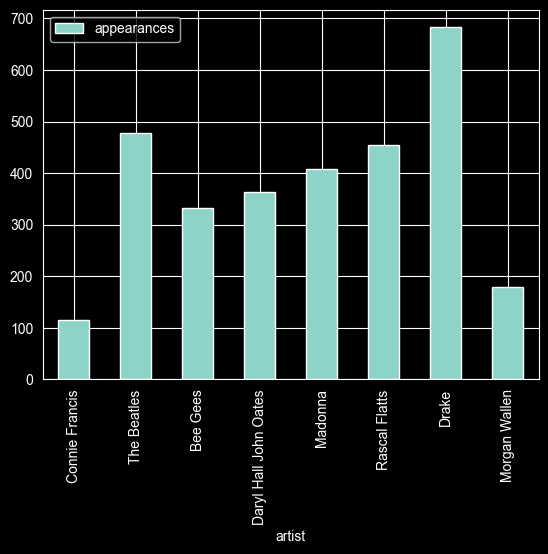

In [14]:
dominant_per_decade.plot(x='artist', y='appearances', kind='bar')

In [10]:
# Topp 3 per decennium (mer detalj)
top3_per_decade = (df.groupby(['decade', 'artist'])
                     .size()
                     .reset_index(name='appearances')
                     .sort_values(['decade', 'appearances'], ascending=[True, False])
                     .groupby('decade')
                     .head(3)
                     .reset_index(drop=True))
top3_per_decade

,decade,artist,appearances
0,1950s,Connie Francis,114
1,1950s,Ricky Nelson,110
2,1950s,Pat Boone,109
3,1960s,The Beatles,478
4,1960s,Brenda Lee,408
5,1960s,Elvis Presley With The Jordanaires,392
6,1970s,Bee Gees,333
7,1970s,Chicago,310
8,1970s,Elton John,297
9,1980s,Daryl Hall John Oates,363


In [17]:
# Antal gånger rankad #1 per artist och decennium
no1_artist_per_decade = (df[df['rank'] == 1]
                    .groupby(['decade', 'artist'])
                    .size()
                    .reset_index(name='weeks_at_no1')
                    .sort_values(['decade', 'weeks_at_no1'], ascending=[True, False])
                    .groupby('decade')
                    .first()
                    .reset_index())
no1_artist_per_decade

,decade,artist,weeks_at_no1
0,1950s,Bobby Darin,9
1,1960s,The Beatles,50
2,1970s,Bee Gees,27
3,1980s,Michael Jackson,20
4,1990s,Mariah Carey,42
5,2000s,The Black Eyed Peas,26
6,2010s,Drake,29
7,2020s,BTS,15


In [21]:
# Antal gånger rankad #1 per song och decennium
no1_song_per_decade = (df[df['rank'] == 1]
                    .groupby(['decade', 'song', 'artist'])
                    .size()
                    .reset_index(name='weeks_at_no1')
                    .sort_values(['decade', 'weeks_at_no1'], ascending=[True, False])
                    .groupby('decade')
                    .first()
                    .reset_index())
no1_song_per_decade

,decade,song,artist,weeks_at_no1
0,1950s,Mack The Knife,Bobby Darin,9
1,1960s,Hey Jude,The Beatles,9
2,1970s,You Light Up My Life,Debby Boone,10
3,1980s,Physical,Olivia Newton-John,10
4,1990s,One Sweet Day,Mariah Carey & Boyz II Men,16
5,2000s,I Gotta Feeling,The Black Eyed Peas,14
6,2010s,Old Town Road,Lil Nas X Featuring Billy Ray Cyrus,19
7,2020s,The Box,Roddy Ricch,11
